IMPORT LIBRARIES

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.utils import resample


LOAD DATA

In [ ]:
data = pd.read_csv('/content/Rainfall.csv')


In [ ]:
# Clean column names
data.columns = data.columns.str.strip()

print(data.head())


   day  pressure  maxtemp  temparature  mintemp  dewpoint  humidity  cloud  \
0    1    1025.9     19.9         18.3     16.8      13.1        72     49   
1    2    1022.0     21.7         18.9     17.2      15.6        81     83   
2    3    1019.7     20.3         19.3     18.0      18.4        95     91   
3    4    1018.9     22.3         20.6     19.1      18.8        90     88   
4    5    1015.9     21.3         20.7     20.2      19.9        95     81   

  rainfall  sunshine  winddirection  windspeed  
0      yes       9.3           80.0       26.3  
1      yes       0.6           50.0       15.3  
2      yes       0.0           40.0       14.2  
3      yes       1.0           50.0       16.9  
4      yes       0.0           40.0       13.7  


HANDLE MISSING VALUES

In [ ]:
data["winddirection"] = data["winddirection"].fillna(data["winddirection"].mode()[0])
data["windspeed"] = data["windspeed"].fillna(data["windspeed"].median())


CONVERT TARGET VARIABLE

In [ ]:
data["rainfall"] = data["rainfall"].map({"yes": 1, "no": 0})

In [ ]:
# Safety check
data = data.dropna(subset=["rainfall"])

print(data["rainfall"].value_counts())

rainfall
1    249
0    117
Name: count, dtype: int64


BALANCE DATA (OVERSAMPLING)

In [ ]:
df_majority = data[data['rainfall'] == 1]
df_minority = data[data['rainfall'] == 0]

df_minority_upsampled = resample(df_minority,
                                replace=True,
                                n_samples=len(df_majority),
                                random_state=42)

data_balanced = pd.concat([df_majority, df_minority_upsampled])
data_balanced = data_balanced.sample(frac=1, random_state=42)

print("Balanced Data:\n", data_balanced["rainfall"].value_counts())


Balanced Data:
 rainfall
0    249
1    249
Name: count, dtype: int64


FEATURE SELECTION

In [ ]:
# Drop highly correlated columns (improves accuracy)
data_balanced = data_balanced.drop(columns=['maxtemp', 'temparature', 'mintemp'])


SPLIT DATA

In [ ]:
X = data_balanced.drop("rainfall", axis=1)
y = data_balanced["rainfall"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

TRAIN MODEL

In [ ]:
model = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    random_state=42
)

model.fit(X_train, y_train)


RandomForestClassifier(max_depth=20, n_estimators=200, random_state=42)

PREDICTION

In [ ]:
y_pred = model.predict(X_test)

EVALUATION

In [ ]:
accuracy = accuracy_score(y_test, y_pred)

print("\nAccuracy:", accuracy)
print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))



Accuracy: 0.86

Confusion Matrix:
 [[39  4]
 [10 47]]

Classification Report:
               precision    recall  f1-score   support

           0       0.80      0.91      0.85        43
           1       0.92      0.82      0.87        57

    accuracy                           0.86       100
   macro avg       0.86      0.87      0.86       100
weighted avg       0.87      0.86      0.86       100



PREDICT ON RANDOM DATA

In [ ]:
# Create a random sample (same columns as X)
random_sample = pd.DataFrame([{
    'day': 120,
    'pressure': 1015.5,
    'dewpoint': 18.2,
    'humidity': 85,
    'cloud': 90,
    'sunshine': 2.5,
    'winddirection': 60,
    'windspeed': 25.0
}])


In [ ]:
print("Columns used in model:\n", X.columns)

Columns used in model:
 Index(['day', 'pressure', 'dewpoint', 'humidity', 'cloud', 'sunshine',
       'winddirection', 'windspeed'],
      dtype='object')


In [ ]:
# Predict
prediction = model.predict(random_sample)


In [ ]:
# Output result
if prediction[0] == 1:
    print("Prediction: Rainfall (YES)")
else:
    print("Prediction: No Rainfall (NO)")

Prediction: Rainfall (YES)


ROC CURVE & AUC SCORE

AUC Score: 0.9506323949408404


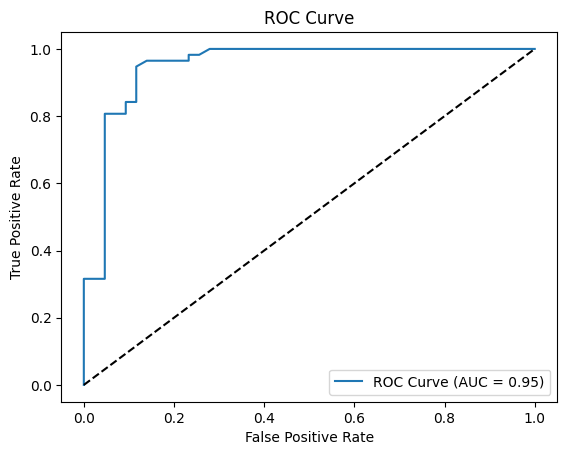

In [ ]:
from sklearn.metrics import roc_curve, roc_auc_score

# Get probability scores (important for ROC)
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

# Calculate AUC score
auc_score = roc_auc_score(y_test, y_prob)

print("AUC Score:", auc_score)

# Plot ROC Curve
import matplotlib.pyplot as plt

plt.figure()
plt.plot(fpr, tpr, label="ROC Curve (AUC = %0.2f)" % auc_score)
plt.plot([0, 1], [0, 1], 'k--')  # random line
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()